# Redes Neuronales II — Notebook 04
## Clasificación multiclase en MNIST con PyTorch (réplica del MLP de Keras)

**Objetivo.** Replicar en PyTorch la misma arquitectura del Notebook 03 (784-256-128-10, ReLU, Dropout 0.2, Adam η=1e-3, lote 128, *early stopping* con paciencia 3) y comparar ambos frameworks.

Diferencias conceptuales entre frameworks:

| Aspecto | Keras | PyTorch |
|---|---|---|
| Definición | `keras.Sequential([...])` | `nn.Sequential(...)` / subclase de `nn.Module` |
| Bucle de entrenamiento | `model.fit()` (implícito) | Explícito: `forward → loss → loss.backward() → optimizer.step()` |
| Backpropagation | Automática dentro de `fit` | Explícita con `loss.backward()` (autograd) |
| Softmax de salida | Capa `softmax` + `sparse_categorical_crossentropy` | Logits + `nn.CrossEntropyLoss` (aplica *log-softmax* internamente, más estable) |
| Modo entrenamiento/inferencia | Automático | `model.train()` / `model.eval()` (afecta a Dropout) |

En Colab: `Entorno de ejecución → Ejecutar todas`. Usa GPU si está disponible.

In [1]:
import os, json, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("figures", exist_ok=True); os.makedirs("results", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110})
print("PyTorch", torch.__version__, "| dispositivo:", device)

PyTorch 2.14.0+cu130 | dispositivo: cpu


## 1. Carga y preparación (misma partición que en Keras)

In [2]:
train_raw = datasets.MNIST("data", train=True, download=True)
test_raw  = datasets.MNIST("data", train=False, download=True)

def prep(ds):
    x = ds.data.reshape(len(ds.data), -1).float() / 255.0      # aplanar 28x28 -> 784 y normalizar a [0,1]
    return x, ds.targets.clone()

x_all, y_all = prep(train_raw); x_test, y_test = prep(test_raw)
x_train, y_train = x_all[:54000], y_all[:54000]
x_val,   y_val   = x_all[54000:], y_all[54000:]
print("train:", tuple(x_train.shape), "val:", tuple(x_val.shape), "test:", tuple(x_test.shape))

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=128, shuffle=True, generator=g)
val_loader   = DataLoader(TensorDataset(x_val, y_val), batch_size=1024)
test_loader  = DataLoader(TensorDataset(x_test, y_test), batch_size=1024)

train: (54000, 784) val: (6000, 784) test: (10000, 784)


## 2. Definición del modelo
Se usa inicialización **He (Kaiming)** en las capas ReLU, igual que `he_normal` en Keras. La última capa devuelve *logits*; la softmax se aplica dentro de `CrossEntropyLoss` y, en inferencia, con `torch.softmax`.

In [3]:
class MLP(nn.Module):
    def __init__(self, activation="relu", dropout=0.2):
        super().__init__()
        act = nn.ReLU if activation == "relu" else nn.Sigmoid
        self.net = nn.Sequential(
            nn.Linear(784, 256), act(), nn.Dropout(dropout),
            nn.Linear(256, 128), act(), nn.Dropout(dropout),
            nn.Linear(128, 10),                                   # logits
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                if activation == "relu": nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                else: nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x)

model = MLP().to(device)
print(model)
print("Parámetros entrenables:", sum(p.numel() for p in model.parameters() if p.requires_grad))

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
Parámetros entrenables: 235146


## 3. Bucle de entrenamiento explícito (backpropagation con autograd)

In [4]:
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):
    """Si hay optimizer entrena (forward + backward + step); si no, sólo evalúa."""
    train = optimizer is not None
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)                       # forward
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()                      # backpropagation: ∂L/∂θ para todos los pesos
                optimizer.step()                     # actualización de Adam
            total_loss += loss.item() * len(xb); correct += (logits.argmax(1) == yb).sum().item(); n += len(xb)
    return total_loss / n, correct / n

def fit(model, epochs=30, lr=1e-3, patience=3, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    best_loss, best_state, wait = np.inf, None, 0
    for ep in range(1, epochs + 1):
        t = time.time()
        tl, ta = run_epoch(model, train_loader, optimizer)
        vl, va = run_epoch(model, val_loader)
        for k, v in zip(hist, (tl, ta, vl, va)): hist[k].append(v)
        if verbose:
            print(f"Época {ep:2d} | loss {tl:.4f} | acc {ta:.4f} | val_loss {vl:.4f} | val_acc {va:.4f} | {time.time()-t:.1f}s")
        if vl < best_loss:
            best_loss, best_state, wait = vl, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                if verbose: print(f"Early stopping: sin mejora en val_loss durante {patience} épocas.")
                break
    model.load_state_dict(best_state)                # restaurar mejores pesos
    return hist

### 3.1 Experimento: Sigmoide vs ReLU (5 épocas, sin dropout)

sigmoid: val_acc por época = [0.9317 0.9472 0.96   0.9667 0.9692]


   relu: val_acc por época = [0.967  0.975  0.9755 0.9798 0.9793]


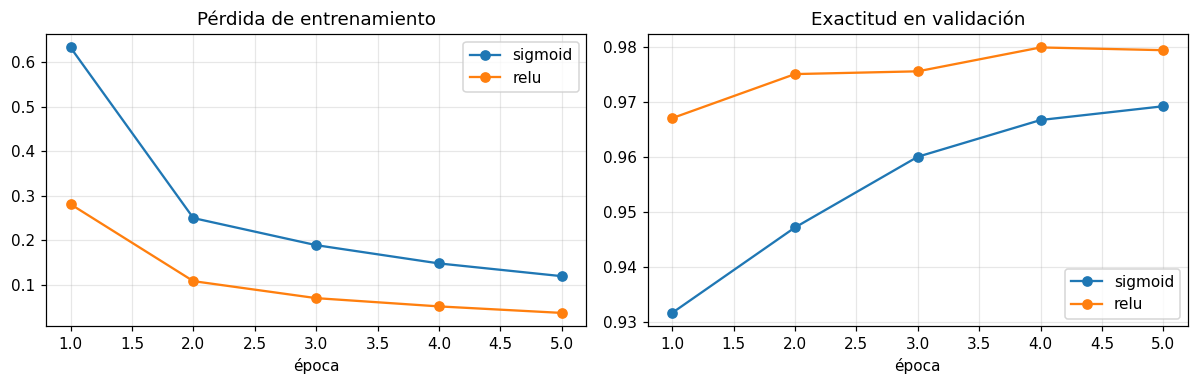

In [5]:
act_hist = {}
for act in ["sigmoid", "relu"]:
    torch.manual_seed(SEED)
    m = MLP(act, dropout=0).to(device)
    act_hist[act] = fit(m, epochs=5, patience=99, verbose=False)
    print(f"{act:>7}: val_acc por época = {np.round(act_hist[act]['val_accuracy'], 4)}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for act, h in act_hist.items():
    ax[0].plot(range(1, 6), h["loss"], "o-", label=act); ax[1].plot(range(1, 6), h["val_accuracy"], "o-", label=act)
ax[0].set_title("Pérdida de entrenamiento"); ax[1].set_title("Exactitud en validación")
for a in ax: a.set_xlabel("época"); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/04_sigmoide_vs_relu.png", bbox_inches="tight"); plt.show()

### 3.2 Entrenamiento del modelo final

Época  1 | loss 0.3602 | acc 0.8908 | val_loss 0.1148 | val_acc 0.9678 | 1.6s


Época  2 | loss 0.1537 | acc 0.9539 | val_loss 0.0870 | val_acc 0.9727 | 1.6s


Época  3 | loss 0.1090 | acc 0.9667 | val_loss 0.0737 | val_acc 0.9775 | 1.6s


Época  4 | loss 0.0876 | acc 0.9735 | val_loss 0.0710 | val_acc 0.9767 | 1.6s


Época  5 | loss 0.0737 | acc 0.9767 | val_loss 0.0725 | val_acc 0.9775 | 1.5s


Época  6 | loss 0.0608 | acc 0.9811 | val_loss 0.0747 | val_acc 0.9762 | 1.6s


Época  7 | loss 0.0519 | acc 0.9832 | val_loss 0.0629 | val_acc 0.9825 | 1.8s


Época  8 | loss 0.0481 | acc 0.9845 | val_loss 0.0669 | val_acc 0.9803 | 1.9s


Época  9 | loss 0.0437 | acc 0.9859 | val_loss 0.0684 | val_acc 0.9805 | 1.8s


Época 10 | loss 0.0375 | acc 0.9875 | val_loss 0.0666 | val_acc 0.9828 | 1.8s
Early stopping: sin mejora en val_loss durante 3 épocas.

Tiempo de entrenamiento: 16.6 s | épocas ejecutadas: 10


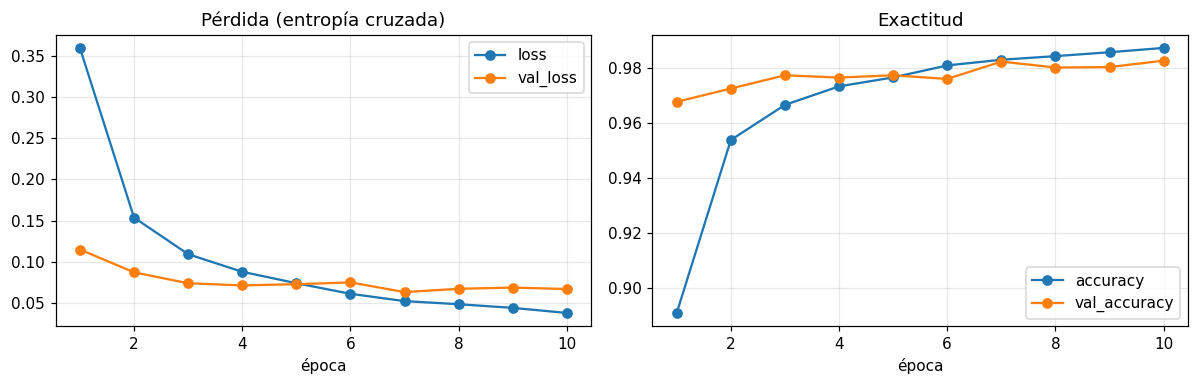

In [6]:
torch.manual_seed(SEED)
model = MLP("relu", dropout=0.2).to(device)
t0 = time.time()
history = fit(model, epochs=30, lr=1e-3, patience=3)
train_time = time.time() - t0
print(f"\nTiempo de entrenamiento: {train_time:.1f} s | épocas ejecutadas: {len(history['loss'])}")

h = pd.DataFrame(history); h.index += 1
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
h[["loss", "val_loss"]].plot(ax=ax[0], marker="o", title="Pérdida (entropía cruzada)")
h[["accuracy", "val_accuracy"]].plot(ax=ax[1], marker="o", title="Exactitud")
for a in ax: a.set_xlabel("época"); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/04_curvas_pytorch.png", bbox_inches="tight"); plt.show()

## 4. Evaluación en test

In [7]:
model.eval()
with torch.no_grad():
    logits = torch.cat([model(xb.to(device)).cpu() for xb, _ in test_loader])
probs = torch.softmax(logits, dim=1).numpy()
y_pred, y_true = probs.argmax(1), y_test.numpy()
test_loss = criterion(logits, y_test).item()
test_acc = (y_pred == y_true).mean()
print(f"Pérdida test = {test_loss:.4f} | Exactitud test = {test_acc:.4f} | Errores = {(y_pred != y_true).sum()} de {len(y_true)}\n")
print(classification_report(y_true, y_pred, digits=4))

Pérdida test = 0.0666 | Exactitud test = 0.9796 | Errores = 204 de 10000

              precision    recall  f1-score   support

           0     0.9808    0.9929    0.9868       980
           1     0.9929    0.9885    0.9907      1135
           2     0.9657    0.9835    0.9746      1032
           3     0.9706    0.9822    0.9764      1010
           4     0.9886    0.9725    0.9805       982
           5     0.9853    0.9776    0.9814       892
           6     0.9957    0.9749    0.9852       958
           7     0.9702    0.9825    0.9763      1028
           8     0.9721    0.9651    0.9686       974
           9     0.9752    0.9742    0.9747      1009

    accuracy                         0.9796     10000
   macro avg     0.9797    0.9794    0.9795     10000
weighted avg     0.9797    0.9796    0.9796     10000



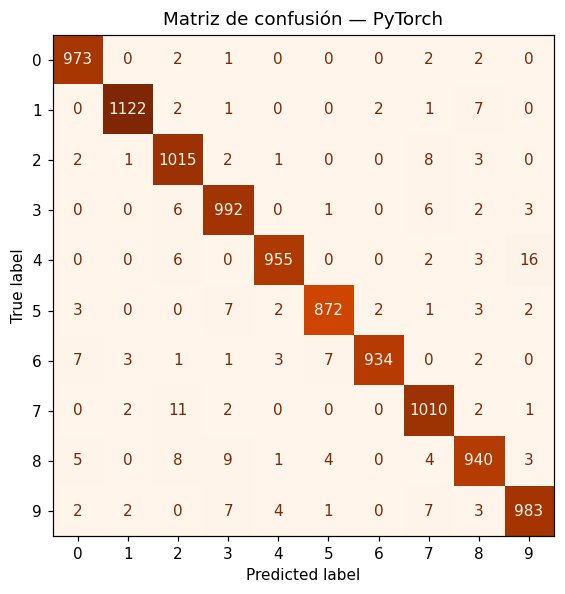

In [8]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Oranges", colorbar=False, values_format="d")
ax.set_title("Matriz de confusión — PyTorch")
plt.tight_layout(); plt.savefig("figures/04_confusion_pytorch.png", bbox_inches="tight"); plt.show()

torch.save(model.state_dict(), "results/mlp_mnist_pytorch.pt")
results = {"framework": "PyTorch", "version": torch.__version__, "test_accuracy": float(test_acc), "test_loss": float(test_loss),
           "epochs": len(history["loss"]), "train_time_s": round(train_time, 1),
           "params": int(sum(p.numel() for p in model.parameters())), "errors": int((y_pred != y_true).sum()),
           "val_accuracy_best": float(max(history["val_accuracy"])), "history": history,
           "activation_experiment": {k: v["val_accuracy"] for k, v in act_hist.items()}}
json.dump(results, open("results/pytorch_mnist.json", "w"), indent=2)

## 5. Comparación Keras vs PyTorch
Se leen los resultados guardados por el Notebook 03 (`results/keras_mnist.json`). Si no existe, ejecute primero ese notebook en la misma sesión de Colab.

                         version  params  epochs  train_time_s  \
framework                                                        
TensorFlow + Keras        2.21.0  235146      12          24.6   
PyTorch             2.14.0+cu130  235146      10          16.6   

                    val_accuracy_best  test_accuracy  test_loss  errors  
framework                                                                
TensorFlow + Keras             0.9828         0.9822     0.0626     178  
PyTorch                        0.9828         0.9796     0.0666     204  


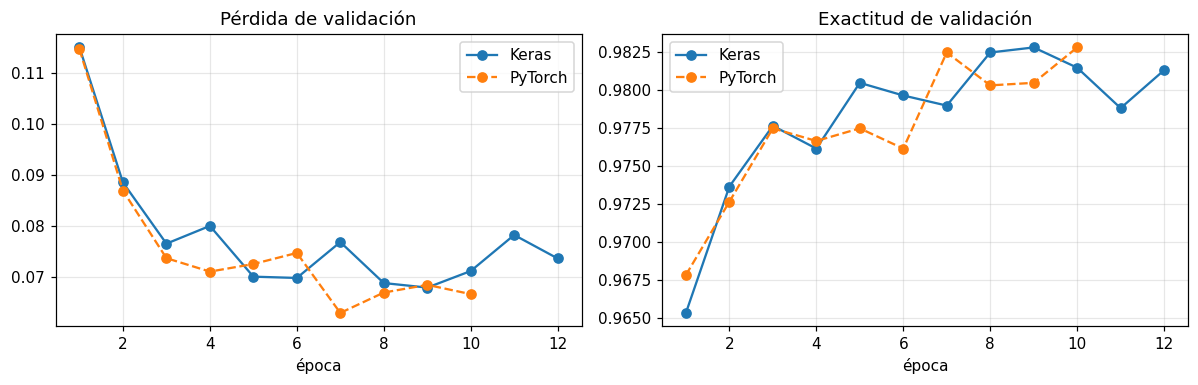

In [9]:
if os.path.exists("results/keras_mnist.json"):
    kr = json.load(open("results/keras_mnist.json"))
    cols = ["framework", "version", "params", "epochs", "train_time_s", "val_accuracy_best", "test_accuracy", "test_loss", "errors"]
    comp = pd.DataFrame([{c: kr[c] for c in cols}, {c: results[c] for c in cols}]).set_index("framework")
    display(comp.round(4)) if "display" in dir() else print(comp.round(4))
    comp.to_csv("results/comparacion_frameworks.csv")

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    for name, hh, st in [("Keras", kr["history"], "-"), ("PyTorch", history, "--")]:
        e = range(1, len(hh["val_loss"]) + 1)
        ax[0].plot(e, hh["val_loss"], st, marker="o", label=name); ax[1].plot(e, hh["val_accuracy"], st, marker="o", label=name)
    ax[0].set_title("Pérdida de validación"); ax[1].set_title("Exactitud de validación")
    for a in ax: a.set_xlabel("época"); a.legend(); a.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig("figures/04_keras_vs_pytorch.png", bbox_inches="tight"); plt.show()
else:
    print("No se encontró results/keras_mnist.json: ejecute primero el Notebook 03.")

## 6. Análisis

* La réplica en PyTorch, con el mismo número de parámetros (235 146) e hiperparámetros, alcanza una exactitud de test prácticamente igual a la de Keras (diferencias de décimas de punto porcentual, atribuibles a la inicialización aleatoria, al orden de los mini-lotes y a detalles de implementación de Adam/Dropout en cada framework).
* **PyTorch** exige escribir el bucle de entrenamiento, lo que hace visibles los pasos de backpropagation (`zero_grad → backward → step`) y da control total (métricas, *early stopping*, dispositivos). **Keras** reduce el código a `compile` + `fit`, ideal para prototipado rápido.
* El experimento de activaciones reproduce en ambos frameworks el mismo resultado: **ReLU supera a Sigmoide** con igual presupuesto de épocas.